Chapter 27
# 主成分分析
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as pdr
# pip install pandas_datareader
import seaborn as sns
import statsmodels.multivariate.pca as pca #主成分分析

In [2]:
# 下载数据
df = pdr.data.DataReader(['DGS6MO','DGS1',
                          'DGS2','DGS5',
                          'DGS7','DGS10', # 需要的数据
                          'DGS20','DGS30'],
                          data_source='fred',
                          start='01-01-2022',  # 时间
                          end='12-31-2022')
df = df.dropna() # 删除NaN的缺失值
# 如果无法下载数据，请用pandas.read_csv() 读取配套文件

In [3]:
df  # 打印数据

,DGS6MO,DGS1,DGS2,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,
2022-01-03,0.22,0.40,0.78,1.37,1.55,1.63,2.05,2.01
2022-01-04,0.22,0.38,0.77,1.37,1.57,1.66,2.10,2.07
2022-01-05,0.22,0.41,0.83,1.43,1.62,1.71,2.12,2.09
2022-01-06,0.23,0.45,0.88,1.47,1.66,1.73,2.12,2.09
2022-01-07,0.24,0.43,0.87,1.50,1.69,1.76,2.15,2.11
...,...,...,...,...,...,...,...,...
2022-12-23,4.67,4.66,4.31,3.86,3.83,3.75,3.99,3.82
2022-12-27,4.76,4.75,4.32,3.94,3.93,3.84,4.10,3.93
2022-12-28,4.75,4.71,4.31,3.97,3.97,3.88,4.13,3.98


In [4]:
# 修改数据帧列标签
df = df.rename(columns={'DGS6MO': '0.5 yr',
                        'DGS1': '1 yr',
                        'DGS2': '2 yr',
                        'DGS5': '5 yr',
                        'DGS7': '7 yr',
                        'DGS10': '10 yr',
                        'DGS20': '20 yr',
                        'DGS30': '30 yr'})

In [6]:
df.head()  # 查看数据

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-03,0.22,0.40,0.78,1.37,1.55,1.63,2.05,2.01
2022-01-04,0.22,0.38,0.77,1.37,1.57,1.66,2.10,2.07
2022-01-05,0.22,0.41,0.83,1.43,1.62,1.71,2.12,2.09
2022-01-06,0.23,0.45,0.88,1.47,1.66,1.73,2.12,2.09
2022-01-07,0.24,0.43,0.87,1.50,1.69,1.76,2.15,2.11


##绘制图像

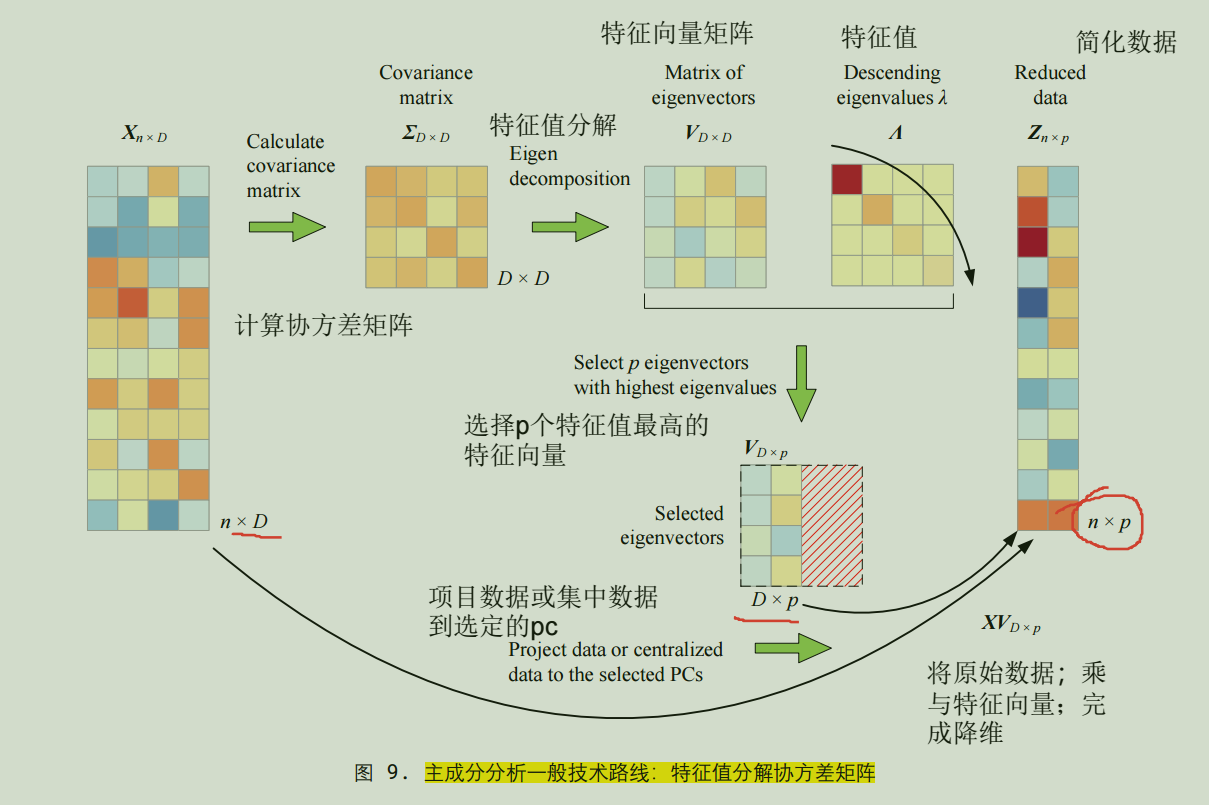

PCA 的一般步骤如下：

计算原始数据 Xn × D的协方差矩阵 (covariance matrix) ΣD × D；

  对 Σ 特征值分解 (Eigen Value Decomposition, EVD)，获得特征值 λi与特征向量矩阵 VD ×
D；


◄ 对特征值 λi从大到小排序，选择其中特征值最大的 p 个特征向量；


◄ 将原始数据 (中心化数据) 投影到这 p 个正交向量构建的低维空间中，获得得分 Zn × p。

很多时候，在第一步中，我们先标准化 (standardization) 原始数据，即计算 X 的 Z 分数。
标准化防止不同特征上方差差异过大。而有些情况，对原始数据 Xn × D进行中心化 (去均值) 就足够
了，即将数据质心 (centroid) 移到原点 (origin)。


下面，我们用不同年期利率时间序列数据介绍如何使用 Statsmodels 函数完成主成分分析。图
10 所示为 2022 年 8 个不同年期利率走势，也就是说数据有 8 个特征 (维度)。

从时间序列的涨跌，我们可以看到明显的联动性 (co-movement)。图 13 所示的相
关性系数矩阵则“量化”联动性。主成分分析 PCA 便可以帮助我们分析这种联动性。


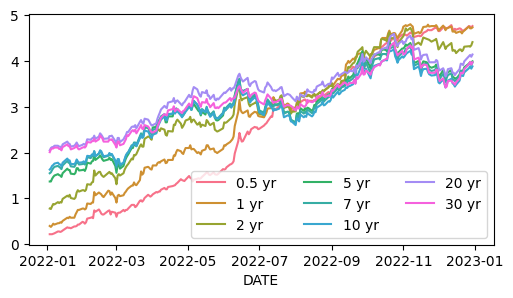

In [7]:
# 绘制利率走势
fig, ax = plt.subplots(figsize = (6,3))

#seaborn.lineplot() 绘制利率走势线图
# 每一列一条曲线
sns.lineplot(df,markers=False,dashes=False,
             palette = "husl",ax = ax)
ax.legend(loc='lower right',ncol=3) # 图例有三列

用 pct_change() 计算日收益率。如图 11 所示，日收益率是用来衡量股票、利率在一天内的
价格变动幅度的指标。日收益率通常以百分比形式表示，回顾前文介绍的计算方法，具体为：日收益率
= (当日收盘价 − 前一日收盘价) / 前一日收盘价 × 100%。


In [9]:
# 计算日收益率
X_df = df.pct_change()
X_df = X_df.dropna()

日收益率数据 X 是下文主成分分析对象。


In [10]:
X_df

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,0.000000,-0.050000,-0.012821,0.000000,0.012903,0.018405,0.024390,0.029851
2022-01-05,0.000000,0.078947,0.077922,0.043796,0.031847,0.030120,0.009524,0.009662
2022-01-06,0.045455,0.097561,0.060241,0.027972,0.024691,0.011696,0.000000,0.000000
2022-01-07,0.043478,-0.044444,-0.011364,0.020408,0.018072,0.017341,0.014151,0.009569
2022-01-10,0.166667,0.069767,0.057471,0.020000,0.011834,0.011364,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2022-12-23,0.002146,0.004310,0.016509,0.018470,0.015915,0.021798,0.020460,0.024129
2022-12-27,0.019272,0.019313,0.002320,0.020725,0.026110,0.024000,0.027569,0.028796
2022-12-28,-0.002101,-0.008421,-0.002315,0.007614,0.010178,0.010417,0.007317,0.012723


# 可视化收益率

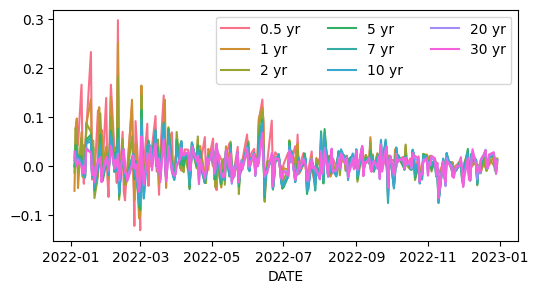

In [11]:
# 可视化收益率
# 这个图像是日收益曲线
fig, ax = plt.subplots(figsize = (6,3))
sns.lineplot(X_df,markers=False,
             dashes=False,palette = "husl",ax = ax)
ax.legend(loc='upper right',ncol=3)

用 **seaborn.pairplot() 绘制成对散点图**，用来理解变量之间的关系和分布情况。

**对角线上的子图默认是每个变量的直方图**，图 12 将对角线子图修改为概率密度估计线图，这是下一节要介绍的
内容。

*非对角线上的图形是变量之间的散点图*，图 12 仅仅保留了下三角部分子图。


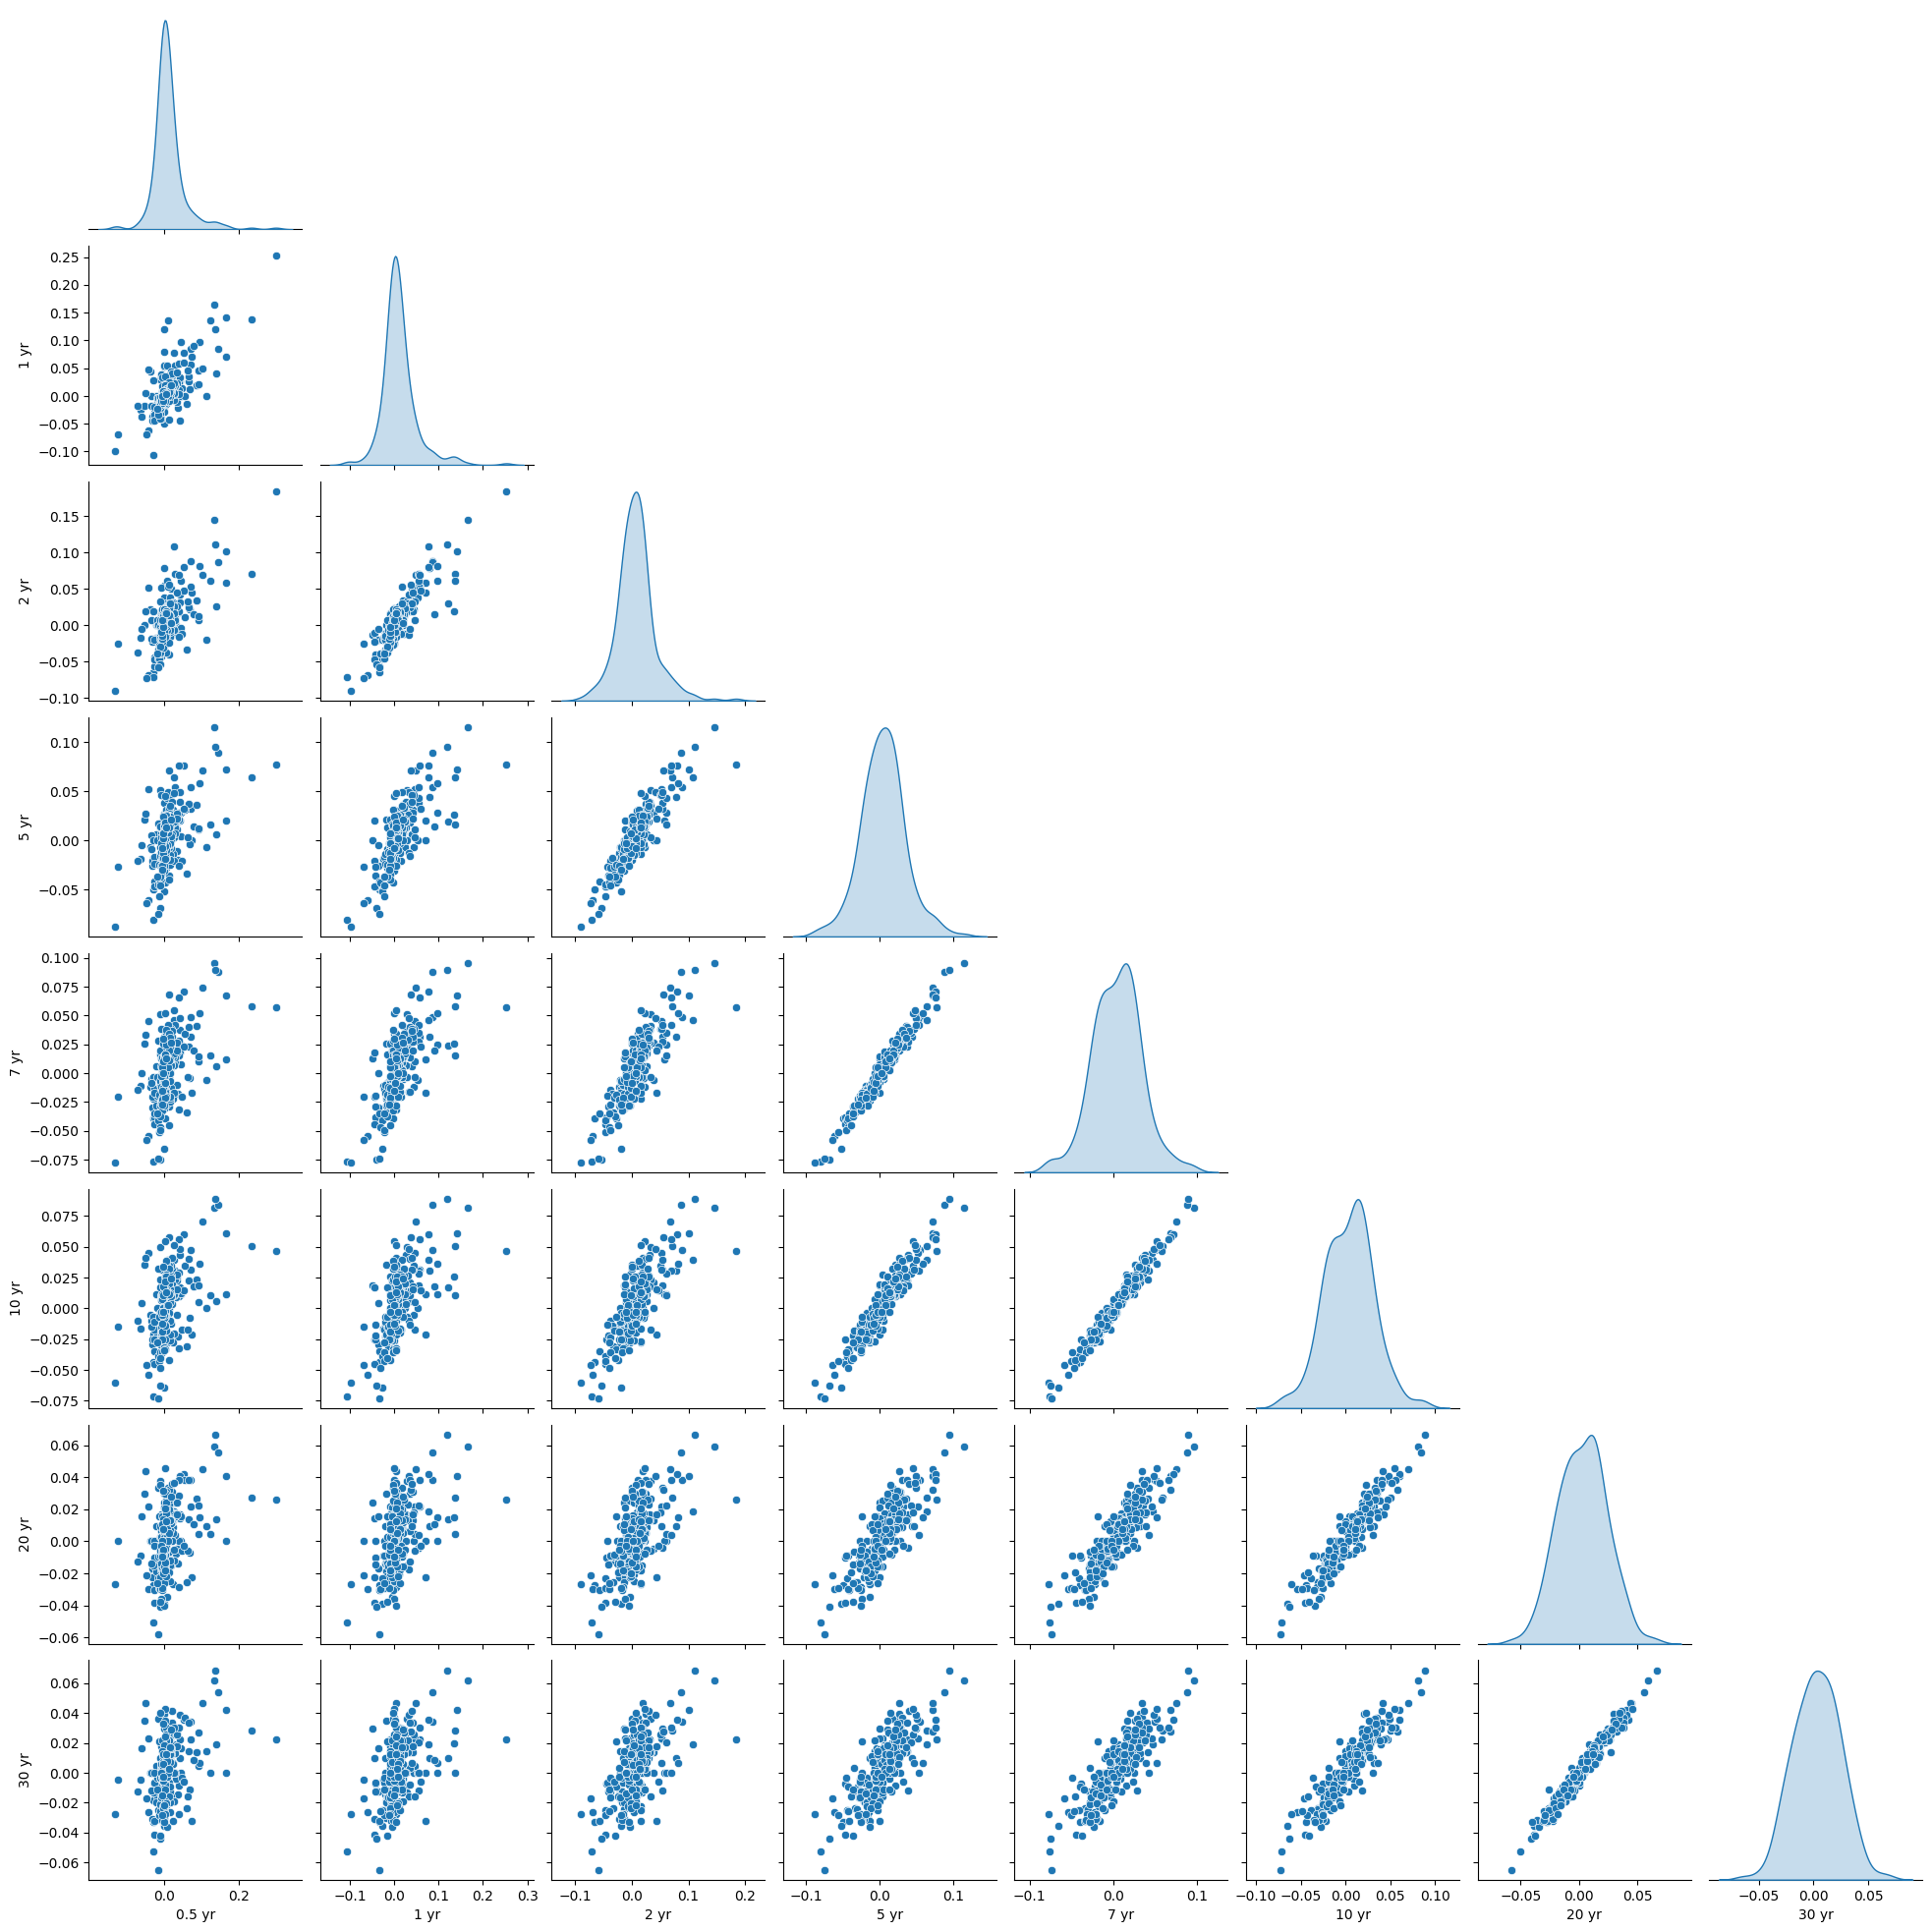

In [12]:
# 成对特征散点图
sns.pairplot(X_df, corner=True, diag_kind="kde") # 对角线为kde

##计算日收益的相关性系数矩阵

In [13]:
# 相关性系数矩阵
C = X_df.corr()

In [14]:
C # 数据就是相对应的系数

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
0.5 yr,1.000000,0.741326,0.658817,0.547214,0.508018,0.469002,0.395009,0.365413
1 yr,0.741326,1.000000,0.877098,0.741927,0.685748,0.633442,0.497752,0.466968
2 yr,0.658817,0.877098,1.000000,0.899742,0.838473,0.782254,0.637459,0.593849
5 yr,0.547214,0.741927,0.899742,1.000000,0.982671,0.951628,0.833816,0.793134
7 yr,0.508018,0.685748,0.838473,0.982671,1.000000,0.983504,0.894960,0.857845
10 yr,0.469002,0.633442,0.782254,0.951628,0.983504,1.000000,0.939536,0.915748
20 yr,0.395009,0.497752,0.637459,0.833816,0.894960,0.939536,1.000000,0.981736
30 yr,0.365413,0.466968,0.593849,0.793134,0.857845,0.915748,0.981736,1.000000


##用 seaborn.heatmap() 可视化相关性系数矩阵。热图

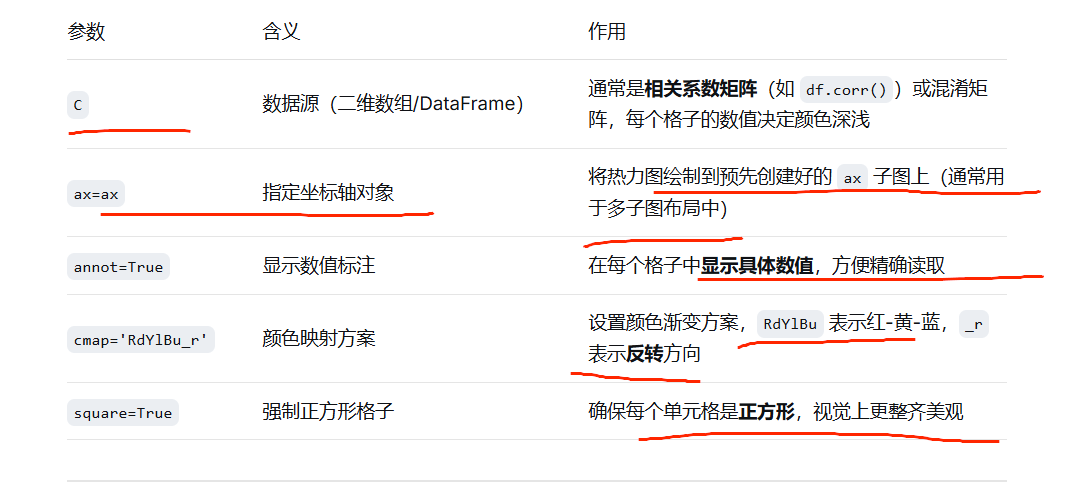

<Axes: >

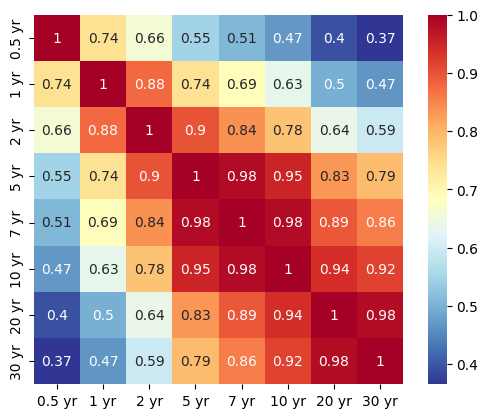

In [16]:
fig, ax = plt.subplots()
sns.heatmap(C, ax = ax,
            annot=True,
            cmap = 'RdYlBu_r',
            square = True)
# C：相关性系数矩阵； ax：对应的轴对象
# annot=True,显示数值标注


# 主成分分析

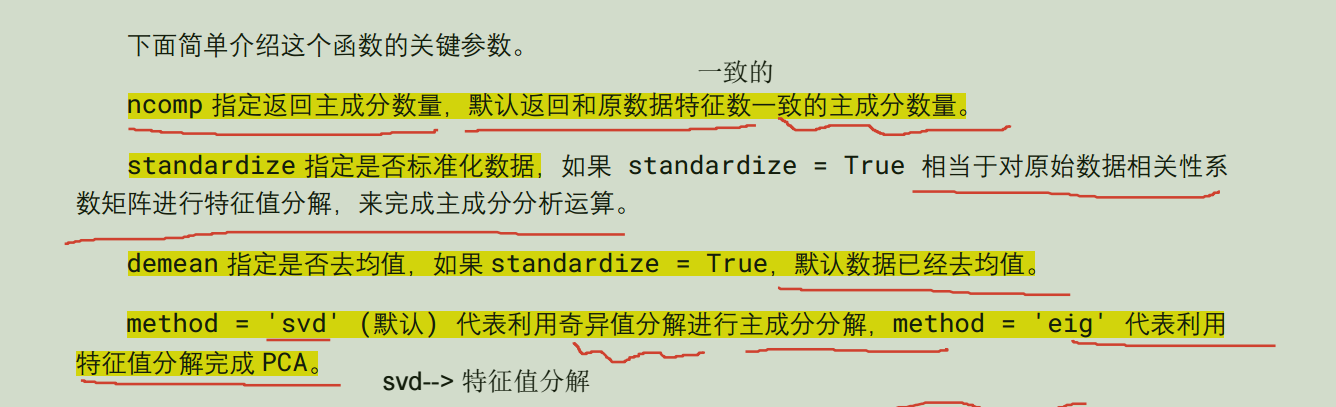

下面简单介绍这个函数的关键参数。

ncomp 指定返回主成分数量，默认返回和原数据特征数一致的主成分数量。

standardize 指定是否标准化数据，如果 standardize = True 相当于对原始数据相关性系

数矩阵进行特征值分解，来完成主成分分析运算。

demean 指定是否去均值，如果 standardize = True，默认数据已经去均值。

method = 'svd' (默认) 代表利用奇异值分解进行主成分分解，method = 'eig' 代表利用
特征值分解完成 PCA。


In [17]:
# 主成分分析；X_df:日收益数据：standardize;标准化
pca_model = pca.PCA(X_df, standardize=True)

In [18]:
pca_model

Principal Component Analysis(nobs: 248, nvar: 8, transformation: Standardize (Correlation), normalization: True, number of components: 8, SVD, id: 0x7b0d2c832f90)

## 提取特征值

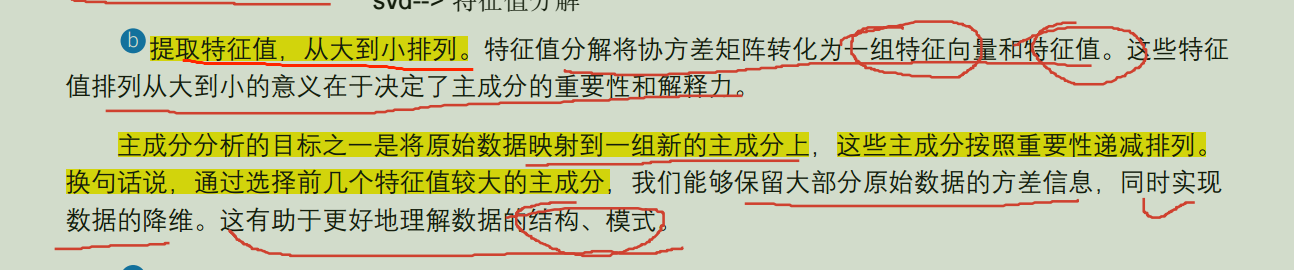

In [19]:
variance_V = pca_model.eigenvals
# 计算主成分的方差解释比例

In [20]:
variance_V # 每一个特征的特征值； 从大到小排列

,eigenvals
0,1537.153508
1,288.888499
2,95.836789
3,37.974147
4,16.245787
5,3.860075
6,2.768714
7,1.272481


In [23]:
variance_V.shape

(8,)

In [24]:
variance_V.sum()

np.float64(1984.0000000000016)

计算每个特征值的比列

In [21]:
explained_var_ratio = variance_V / variance_V.sum() #

In [22]:
explained_var_ratio

,eigenvals
0,0.774775
1,0.145609
2,0.048305
3,0.019140
4,0.008188
5,0.001946
6,0.001396
7,0.000641


计算特征数量

In [30]:
np.arange(len(variance_V))

array([0, 1, 2, 3, 4, 5, 6, 7])

In [26]:
PC_range = np.arange(len(variance_V)) + 1 #计算特征数量
# 广播

In [29]:
PC_range

array([1, 2, 3, 4, 5, 6, 7, 8])

In [28]:
labels = ['$PC_' + str(index) + '$' for index in PC_range]
labels # 生成标签

['$PC_1$',
 '$PC_2$',
 '$PC_3$',
 '$PC_4$',
 '$PC_5$',
 '$PC_6$',
 '$PC_7$',
 '$PC_8$']

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_881/3361017523.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('Eigen value $\lambda$ (PC variance)', color='b')


(0.9, 8.1)

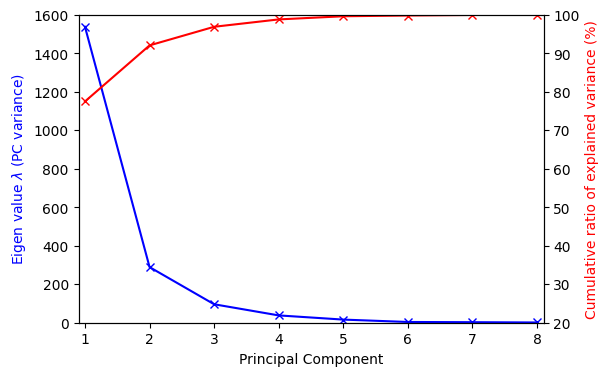

In [32]:
# 陡坡图
fig, ax1 = plt.subplots(figsize = (6,4))

# PC_range：特征标签； variance_V：特征值
# x，y; b： 蓝色
ax1.plot(PC_range, variance_V, 'b', marker = 'x')

ax1.set_xlabel('Principal Component') # 标签
ax1.set_ylabel('Eigen value $\lambda$ (PC variance)', color='b')
ax1.set_ylim(0,1600); ax1.set_xticks(PC_range) #范围

ax2 = ax1.twinx() #增加双 y 轴的右侧纵轴对象。也就是在右侧画图

#explained_var_ratio是特征值比例；
# np.cumsum(explained_var_ratio)*100；计算每一个数据的总和
# 也就是前三列就占据95%
ax2.plot(PC_range, np.cumsum(explained_var_ratio)*100,
         'r', marker = 'x')
ax2.set_ylabel('Cumulative ratio of explained variance (%)',
               color='r')
ax2.set_ylim(20,100)
ax2.set_xlim(PC_range.min() - 0.1,PC_range.max() + 0.1)

##PCA载荷

In [35]:
pca_model.loadings

,comp_0,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7
0.5 yr,0.256636,-0.570500,-0.715678,-0.309866,-0.003309,0.020316,-0.004942,0.002794
1 yr,0.317182,-0.488501,0.197301,0.699507,0.359038,-0.038408,0.042999,0.017098
2 yr,0.358665,-0.294732,0.403551,-0.081386,-0.751605,0.005726,-0.208130,-0.082191
5 yr,0.389874,0.018947,0.280251,-0.362178,0.142643,0.071499,0.637797,0.453522
7 yr,0.391000,0.125592,0.160478,-0.295593,0.338178,-0.106089,0.002534,-0.769800
10 yr,0.387324,0.215072,0.039425,-0.140687,0.291588,0.211512,-0.707096,0.390681
20 yr,0.359370,0.363357,-0.270587,0.206428,-0.167919,-0.758343,0.030811,0.136983
30 yr,0.347625,0.393208,-0.327046,0.356505,-0.241328,0.601574,0.216989,-0.152560


提取前三列

In [33]:
# PCA载荷
# 提取前三列
loadings= pca_model.loadings[['comp_0','comp_1','comp_2']]

In [36]:
loadings

,comp_0,comp_1,comp_2
0.5 yr,0.256636,-0.570500,-0.715678
1 yr,0.317182,-0.488501,0.197301
2 yr,0.358665,-0.294732,0.403551
5 yr,0.389874,0.018947,0.280251
7 yr,0.391000,0.125592,0.160478
10 yr,0.387324,0.215072,0.039425
20 yr,0.359370,0.363357,-0.270587
30 yr,0.347625,0.393208,-0.327046


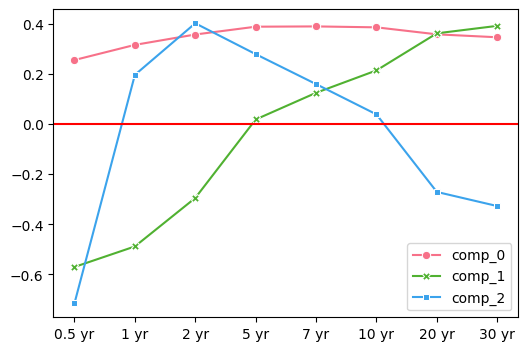

In [37]:
fig, ax = plt.subplots(figsize = (6,4))

# 每一列就一条曲线
sns.lineplot(data=loadings,
             markers=True, dashes=False, palette = "husl")

# 也就是 x 轴
plt.axhline(y=0, color='r', linestyle='-')

##用前3主成分获得还原数据

In [38]:
# 用前3主成分获得还原数据
X_df_ = pca_model.project(3)

In [39]:
X_df_

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,-0.005386,-0.034163,-0.023716,0.000865,0.010535,0.018231,0.026793,0.029905
2022-01-05,0.005757,0.071299,0.071145,0.051217,0.040478,0.030015,0.007871,0.004678
2022-01-06,0.053490,0.079956,0.064257,0.035970,0.024907,0.015218,-0.001566,-0.004672
2022-01-07,0.025542,-0.010179,-0.010621,0.001613,0.007636,0.012664,0.018902,0.021008
2022-01-10,0.159292,0.088729,0.047732,0.017761,0.011523,0.007153,0.003076,0.002027
...,...,...,...,...,...,...,...,...
2022-12-23,0.003293,0.005249,0.010820,0.019059,0.021439,0.022671,0.020376,0.021263
2022-12-27,0.023217,0.007769,0.010369,0.020682,0.024566,0.027030,0.026337,0.027827
2022-12-28,-0.004015,-0.005344,-0.001213,0.005518,0.007933,0.009767,0.010771,0.011566


##比较原始数据和还原数据

In [40]:
list(X_df_.columns)

['0.5 yr', '1 yr', '2 yr', '5 yr', '7 yr', '10 yr', '20 yr', '30 yr']

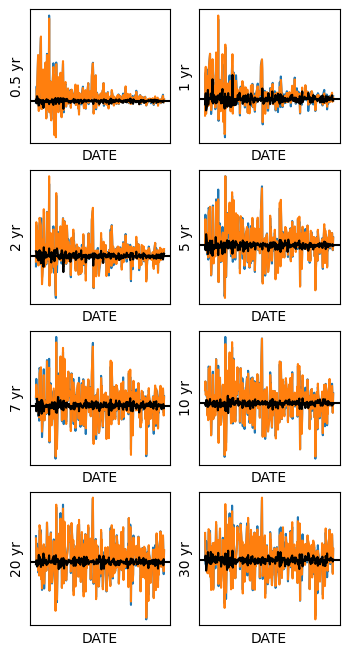

In [41]:
# 比较原始数据和还原数据
# 线图
fig, axes = plt.subplots(4,2,figsize=(4,8))
axes = axes.flatten() # 展为一维数组 1*8

# 每一列数据与轴对象axes绑定；类似字典
for col_idx, ax_idx in zip(list(X_df_.columns),axes):
    # 进行划线
    # 第一图为 每个年份的数据（预测的数据）
    # 第二图为 原始的数据
    # 第三图为 实际数据与预测数据的差值的数据
    sns.lineplot(X_df_[col_idx],ax = ax_idx)
    sns.lineplot(X_df[col_idx],ax = ax_idx)
    sns.lineplot(X_df[col_idx] - X_df_[col_idx],
                 c = 'k', ax = ax_idx)
    ax_idx.set_xticks([]); ax_idx.set_yticks([]) # 不显示坐标轴的刻度标记
    ax_idx.axhline(y = 0, c = 'k') # x轴

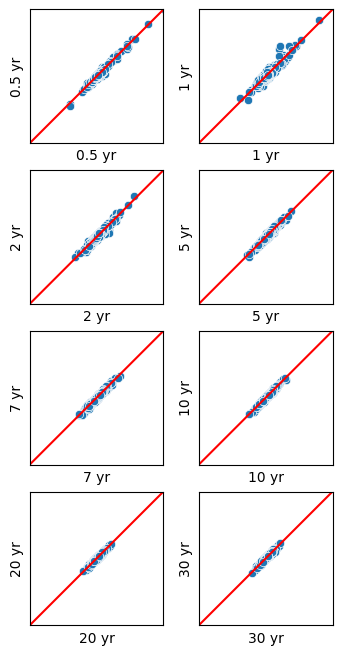

In [42]:
# 散点图
fig, axes = plt.subplots(4,2,figsize=(4,8))
axes = axes.flatten()  # 展为一维数组 1*8

for col_idx, ax_idx in zip(list(X_df_.columns),axes):
    sns.scatterplot(x = X_df_[col_idx],
                    y = X_df[col_idx],
                    ax = ax_idx)
    # x:预测的数据； y：实际数据
    ax_idx.plot([-0.3, 0.3],[-0.3, 0.3],c = 'r') # y=x更好直观的观察数据如果一致；那么数据在直线上
    ax_idx.set_aspect('equal', adjustable='box') # 等比例
    ax_idx.set_xticks([]); ax_idx.set_yticks([]) #不显示坐标轴的刻度标记
    ax_idx.set_xlim(-0.3, 0.3); ax_idx.set_ylim(-0.3, 0.3) # 范围